# Batch a function with vmap

Runnable locally on CPU or on a Cloud TPU VM.

- Write and check a single-example function before batching it.
- Predict vmap input/output axes and distinguish shared parameters from mapped data.
- Verify batched results against a Python-loop reference.
- Relate per-example loss gradients to the gradient of a batch mean.

You have a prediction function that works for one example. Now you need it for a batch. Rather than keep two versions of the model in sync, we’ll tell JAX which input axis contains examples. You’ll compare vmap with a short Python loop and learn which inputs stay shared.

## The idea

Vectorization lets us describe one example clearly and then apply that rule across an axis. The crucial decision is which arguments vary by example and which are shared. `vmap` expresses that decision; it does not require us to write a Python loop or assign hardware threads.

## Map examples without changing the single-example rule

Imagine three observations that use one common weight vector. Each row enters the same dot-product rule, producing one scalar, and the three scalars are stacked. Mapping the observation axis while keeping weights shared means the model is the same for every observation.

Now imagine three different weight vectors, one per observation. Mapping both arguments would answer a different question: three input/model pairs rather than one model applied to a batch. Neither choice is automatically wrong, but only one matches the intended task.

The existing output bars show the lesson's three results, $1,1,8$. Their heights check the values; the axis diagram explains how the rows produced them. Compare against an explicit stack of single-row calls, then permute the rows and predict the same permutation of outputs.

$$
\operatorname{vmap}(f)(X)_i = f(X_i), \qquad i = 0, \dots, B-1
$$

### Mapped rows and shared weights

**Predict:** What should happen if you duplicate an input row while keeping the same shared weights?

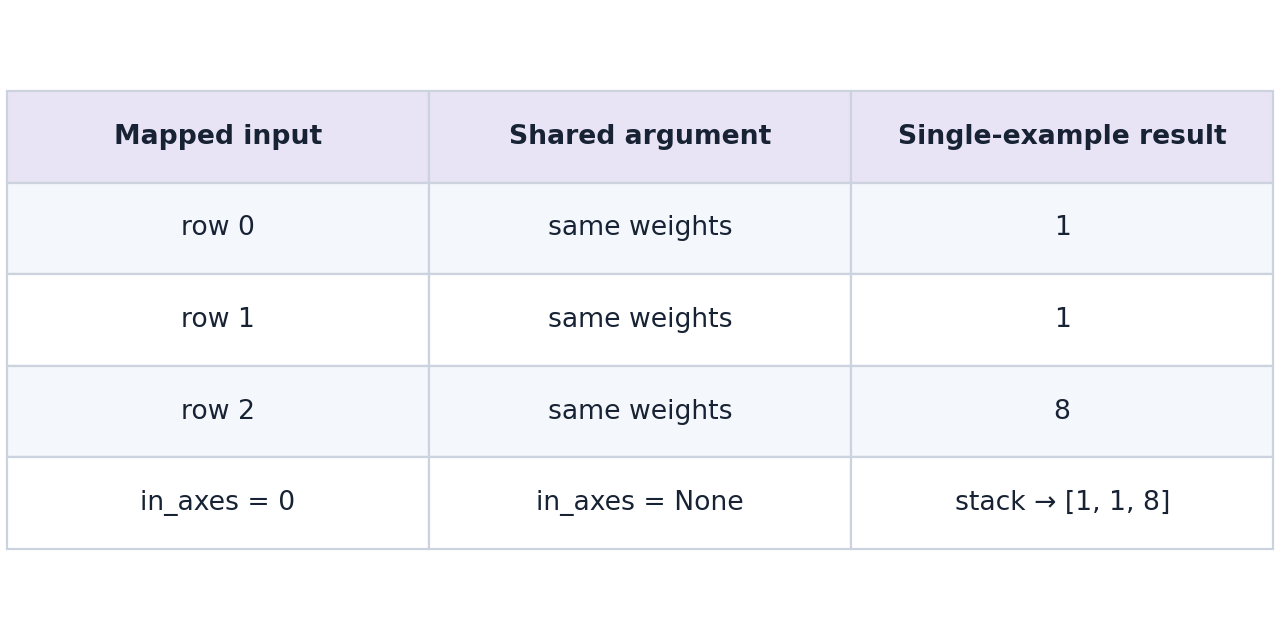

*Architecture and dataflow mechanism diagram.*

Each row enters the same single-example rule with one shared weight vector. The scalar results are stacked in row order. This is a mathematical mapping, not a hardware-thread allocation. Reordering observations should reorder outputs identically.

### Pause and reason

What should happen if you duplicate an input row while keeping the same shared weights?

<details><summary>Compare your reasoning</summary>

The duplicated row should produce the same deterministic output. If it does not, inspect argument mapping and any state/randomness before blaming batching itself.

</details>

## Write down the axis contract

There are three independent questions: which dimension represents examples, which inputs should be repeated unchanged, and where should the collected output axis go? $B$ and $D$ are labels for your reasoning, not named dimensions enforced by JAX.

For the worked example, shared weight is $(2,)$, data is $(3, 2)$, and predictions are $(3,)$. The first row $[1, 1]$ produces $2\cdot1-1\cdot1=1$. The second row $[2, 3]$ also produces $1$. The third $[4, 0]$ produces $8$. Calculate those values before reading the batched call.

```text
single: (D,), (D,) → ()
batched: shared (D,), mapped (B,D) → (B,)
```

## Build a reference that is easy to trust

A small Python loop makes the mapping literal: select each data row, call the original function, and stack its results. Keep that reference for tests even if it is not the production implementation. A matrix-vector product is a second independent formulation for this linear model.

Agreement among the loop, vmap, and matrix product checks different ways of describing the same computation. It does not prove that arbitrary future nonlinear models or new axis conventions are correct. Include asymmetric shapes and distinct row values so a transposition or accidentally shared example is easy to detect.

## Shared does not mean copied or frozen

None in in_axes tells the transformation that an argument has no mapped axis at this level. Every logical example sees the same parameter value. It is still an argument: you can pass a different weight on the next call. It is not a static compilation argument, and None says nothing about whether a gradient can be computed with respect to it.

Setting both arguments to axis $0$ would pair one weight row with one example row. That is useful for an ensemble or a collection of separate models, but it is a different computation from a single shared model. All mapped axes at the same vmap level must have compatible sizes.

## Change layout without changing semantics

Some data arrive with examples in columns: shape $(D, B)$. Mapping axis $1$ selects one column at a time and restores the same single-example shape $(D,)$. in_axes describes that layout. out_axes controls where the new output batch axis is inserted; it does not automatically transpose existing feature dimensions.

For a scalar prediction, output collection gives a vector either way. For a vector-valued feature function, the default produces $(B, K)$; `out_axes=1` gives $(K, B)$. Keep these distinctions explicit at boundaries between a data loader, model, and loss.

## Separate per-example and aggregate gradients

The gradient of a single prediction with respect to its weights is just the input vector. That is a useful first test but not a training loss gradient. A per-example squared error contributes $2(\hat y-y)$ times the input vector. Mapping grad over examples produces an array of shape $(B, D)$.

The gradient of the mean loss has shape $(D,)$. For independent example losses and a plain mean reduction, it equals the mean of the per-example gradients. This equivalence is an important check, and it explains why storing all per-example gradients is not necessary for ordinary mean-loss training. Those arrays can be much larger than the aggregate gradient.

## Compose transformations around the question

`vmap(grad(single_loss))` asks for a gradient per example. `grad(mean(vmap(single_loss)))` asks for the gradient of a batch objective. Both can be useful, but their output shapes and memory needs differ. Once values match independent references, jit can compile the batched transformed function.

Choose the mathematical quantity first and the transformation order second. Do not copy a composition from a tutorial without checking whether it returns predictions, sensitivities, per-example gradients, or a reduced parameter update.

## Step 1: Set up imports and input tensors

Import the required JAX modules and define the initial inputs for batch a function with vmap.

In [1]:
import jax
import jax.numpy as jnp

Establishing explicit input shapes and dtypes first makes the downstream transformation contract deterministic.

## Step 2: Apply the core JAX transformation

Write the core computation and transformation step over the initialized inputs.

In [2]:
def predict(weight, x):
    # Return `jnp.dot(weight, x)` to the caller.
    return jnp.dot(weight, x)
# Construct `weight` via `jnp.array([2., -1.])`
weight = jnp.array([2., -1.])

This stage executes the primary numerical transformation and binds the intermediate outputs.

## Step 3: Verify shapes and numerical invariants

Check that the resulting arrays satisfy the expected shape, dtype, and numerical tolerances.

In [3]:
batch = jnp.array([[1., 1.], [2., 3.], [4., 0.]])
# Vectorize across the batch dimension with `jax.vmap` (`batched`).
batched = jax.vmap(predict, in_axes=(None, 0))
# Print the observed values to compare against the expected result.
# Assert that `jnp.allclose(batched(weight, batch), jnp.array([1.,1.,8.]))`.
assert jnp.allclose(batched(weight, batch), jnp.array([1.,1.,8.]))

These assertions lock in the exact numerical contract before you run the full experiment and variations.

## Run the example

In [4]:
# Batch a function with vmap: Vectorization lets us describe one example clearly and then...
# Import jax for this computation.
import jax
import jax.numpy as jnp
# Function `predict(weight, x)` implementing this stage's computation:
def predict(weight, x):
    # Return `jnp.dot(weight, x)` to the caller.
    return jnp.dot(weight, x)
# Construct `weight` via `jnp.array([2., -1.])`
weight = jnp.array([2., -1.])
# Construct `batch` via `jnp.array([[1., 1.], [2., 3.], [4., 0.]])`
batch = jnp.array([[1., 1.], [2., 3.], [4., 0.]])
# Vectorize across the batch dimension with `jax.vmap` (`batched`).
batched = jax.vmap(predict, in_axes=(None, 0))
# Print the observed values to compare against the expected result.
print(batched(weight, batch))
# Assert that `jnp.allclose(batched(weight, batch), jnp.array([1.,1.,8.]))`.
assert jnp.allclose(batched(weight, batch), jnp.array([1.,1.,8.]))

[1. 1. 8.]


Expected: [$1$. $1$. $8$.]

## Vectorization keeps one result per row

Predict: Which observation produces the largest prediction?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Vectorization keeps one result per row
# Compute `visual_data` from `{'kind': 'bar', 'labels': ['row 0', 'row 1', 'row 2'...`
visual_data = {'kind': 'bar', 'labels': ['row 0', 'row 1', 'row 2'], 'ylabel': 'prediction', 'series': [{'label': 'vmap output', 'y': batched(weight, batch).tolist()}]}

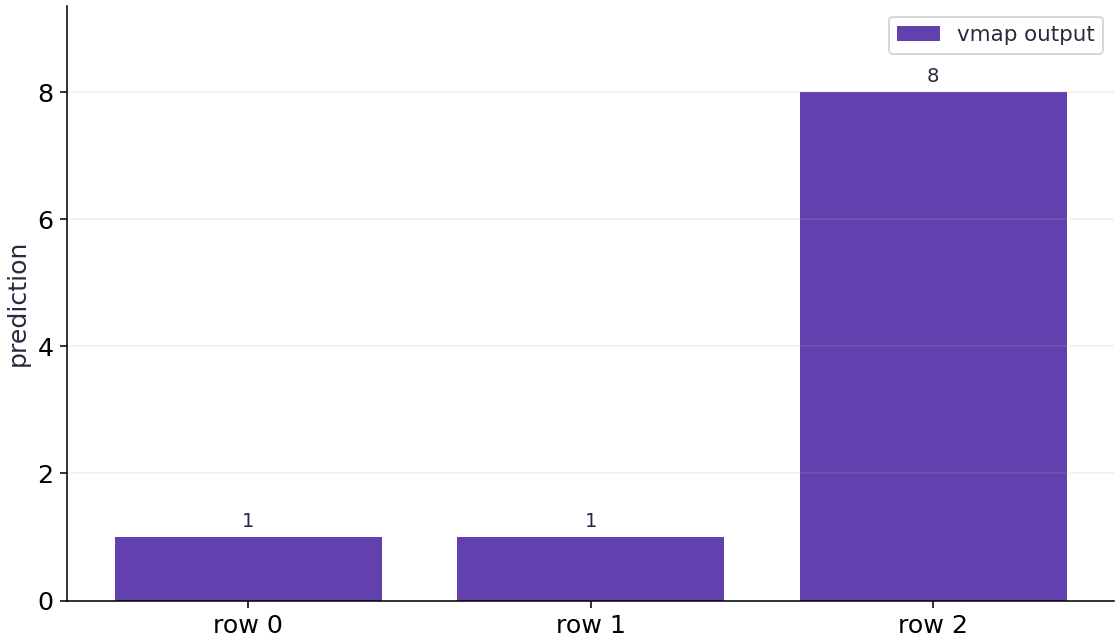

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Each bar belongs to one input row, and its height is that row’s scalar prediction. Reading left to right gives $1$, $1$, and $8$. The horizontal positions are row labels, not successive training steps.

The same weights $(2,-1)$ are used for every row. The first input $(1,1)$ gives $2-1=1$; the second $(2,3)$ gives $4-3=1$; the third $(4,0)$ gives $8-0=8$.

### Connect it to the computation

`vmap` applies the single-example dot product across the batch and keeps one answer per row. Equal heights for the first two bars do not mean those inputs were equal; different inputs can have the same dot product.

There are three outputs because there are three observations. Summing across the whole batch would instead collapse these answers into one scalar. The figure verifies what vectorization computes; the bar heights say nothing about how long it takes.

## Verify against a loop and a matrix product

Predict: Predict the values and output shape. Which reference will catch an incorrectly mapped parameter axis?

In [7]:
# Experiment — Verify against a loop and a matrix product: The loop makes example selection explicit; the matrix product...
loop_predictions = jnp.stack([predict(weight, row) for row in batch])
# Run `batched` to compute `vector_predictions`.
vector_predictions = batched(weight, batch)
# Perform matrix / vector contraction (`@`) to compute `matrix_predictions`.
matrix_predictions = batch @ weight
# Check tensor shape invariant: `vector_predictions.shape == (3,)`
assert vector_predictions.shape == (3,)
# Assert that `jnp.allclose(vector_predictions, loop_predictions)`.
assert jnp.allclose(vector_predictions, loop_predictions)
# Assert that `jnp.allclose(vector_predictions, matrix_predictions)`.
assert jnp.allclose(vector_predictions, matrix_predictions)
# Print the observed values to compare against the expected result.
print("loop / vmap / matmul:", loop_predictions, vector_predictions, matrix_predictions)

loop / vmap / matmul: [1. 1. 8.] [1. 1. 8.] [1. 1. 8.]


Expected: All three formulations produce $[1, 1, 8]$.

The loop makes example selection explicit; the matrix product checks an independent formulation. Keep both as bounded checks of this linear case.

## Move the example axis

Predict: Transpose the batch to shape $(2, 3)$. Which axis must be mapped to give a length-2 input to predict?

In [8]:
# Experiment — Move the example axis: The examples axis and output placement are separate choices.
column_batch = batch.T
# Vectorize across the batch dimension with `jax.vmap` (`column_predict`).
column_predict = jax.vmap(predict, in_axes=(None, 1))
# Assert that `jnp.allclose(column_predict(weight, column_batch), vector_predictions)`.
assert jnp.allclose(column_predict(weight, column_batch), vector_predictions)
# Function `feature_pair(row)` implementing this stage's computation:
def feature_pair(row):
    # Return `jnp.array([jnp.sum(row), jnp.sum(row ** 2)])` to the caller.
    return jnp.array([jnp.sum(row), jnp.sum(row ** 2)])
# Vectorize across the batch dimension with `jax.vmap` (`features_rows`).
features_rows = jax.vmap(feature_pair)(batch)
# Vectorize across the batch dimension with `jax.vmap` (`features_columns`).
features_columns = jax.vmap(feature_pair, out_axes=1)(batch)
# Check tensor shape invariant: `features_rows.shape == (3, 2)`
assert features_rows.shape == (3, 2)
# Check tensor shape invariant: `features_columns.shape == (2, 3)`
assert features_columns.shape == (2, 3)
# Assert that `jnp.allclose(features_rows.T, features_columns)`.
assert jnp.allclose(features_rows.T, features_columns)

Expected: Column-mapped predictions match the original. Feature layouts are $(3, 2)$ and $(2, 3)$.

The examples axis and output placement are separate choices. Use values as well as shapes to verify a layout change.

## Your exercise

Foundation · Compute each prediction gradient with respect to the shared weight. Predict the shape and the derivative of the dot product, then verify against the input batch.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.
- `jax.vmap(fn, in_axes=..., out_axes=...)` — Vectorizes a single-example function across a batch axis without writing a Python loop.

**Step-by-step implementation plan:**
1. Differentiate the objective to obtain `per_example_gradient` via automatic differentiation.
2. Check tensor shape invariant: `per_example_gradient.shape == (3, 2)`
3. Assert that `jnp.allclose(per_example_gradient, batch)`.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Foundation · Compute each prediction gradient with respect to the...
# Differentiate the objective to obtain `per_example_gradient` via automatic differentiation.
per_example_gradient = jax.vmap(...)  # TODO: compute per_example_gradient
# Check tensor shape invariant: `per_example_gradient.shape == (3, 2)`
assert per_example_gradient.shape  # TODO: complete assertion check
# Assert that `jnp.allclose(per_example_gradient, batch)`.
assert jnp.allclose(per_example_gradient, batch)  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Foundation · Compute each prediction gradient with respect to the...
# Differentiate the objective to obtain `per_example_gradient` via automatic differentiation.
# per_example_gradient = jax.vmap(...)  # TODO: compute per_example_gradient
# Check tensor shape invariant: `per_example_gradient.shape == (3, 2)`
# assert per_example_gradient.shape  # TODO: complete assertion check
# Assert that `jnp.allclose(per_example_gradient, batch)`.
# assert jnp.allclose(per_example_gradient, batch)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Foundation · Compute each prediction gradient with respect to the...
# Differentiate the objective to obtain `per_example_gradient` via automatic differentiation.
per_example_gradient = jax.vmap(jax.grad(predict), in_axes=(None, 0))(weight, batch)
# Check tensor shape invariant: `per_example_gradient.shape == (3, 2)`
assert per_example_gradient.shape == (3, 2)
# Assert that `jnp.allclose(per_example_gradient, batch)`.
assert jnp.allclose(per_example_gradient, batch)

## Turn sensitivities into training gradients · Practice

Use targets $[0, 2, 7]$. Define a scalar squared-error function for one example. Compute all per-example parameter gradients and derive the first row independently.

Hint: The per-example squared-loss gradient is $2(\hat y-y)x$: twice the residual times the input. A prediction gradient by itself is not a loss gradient.

### How to write: Turn sensitivities into training gradients — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.
- `jax.vmap(fn, in_axes=..., out_axes=...)` — Vectorizes a single-example function across a batch axis without writing a Python loop.

**Step-by-step implementation plan:**
1. Construct `targets` via `jnp.array([0., 2., 7.])`
2. Function `single_loss(parameters, row, target)` implementing this stage's computation:
3. Return `(predict(parameters, row) - target) ** 2` to the caller.
4. Differentiate the objective to obtain `individual_grads` via automatic differentiation.
5. Perform matrix contraction / projection to compute `manual_grads`.

**Starter code scaffold (fill in the TODOs):**

```python
# Turn sensitivities into training gradients (Practice): The first residual is 1, so the first loss gradient is [2, 2].
# Construct `targets` via `jnp.array([0., 2., 7.])`
targets = jnp.array(...)  # TODO: compute targets
# Function `single_loss(parameters, row, target)` implementing this stage's computation:
def single_loss(parameters, row, target):
    # Return `(predict(parameters, row) - target) ** 2` to the caller.
    return ...  # TODO: return computed result
# Differentiate the objective to obtain `individual_grads` via automatic differentiation.
individual_grads = jax.vmap(...)  # TODO: compute individual_grads
# Perform matrix contraction / projection to compute `manual_grads`.
manual_grads = ...  # TODO: compute manual_grads
# Check tensor shape invariant: `individual_grads.shape == (3, 2)`
assert individual_grads.shape  # TODO: complete assertion check
# Assert that `jnp.allclose(individual_grads, manual_grads)`.
assert jnp.allclose(individual_grads, manual_grads)  # TODO: complete assertion check
# Assert that `jnp.allclose(individual_grads[0], jnp.array([2., 2.]))`.
assert jnp.allclose(individual_grads[0], jnp.array([2., 2.]))  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Turn sensitivities into training gradients (Practice): The first residual is 1, so the first loss gradient is [2, 2].
# Construct `targets` via `jnp.array([0., 2., 7.])`
# targets = jnp.array(...)  # TODO: compute targets
# Function `single_loss(parameters, row, target)` implementing this stage's computation:
# def single_loss(parameters, row, target):
    # Return `(predict(parameters, row) - target) ** 2` to the caller.
#     return ...  # TODO: return computed result
# Differentiate the objective to obtain `individual_grads` via automatic differentiation.
# individual_grads = jax.vmap(...)  # TODO: compute individual_grads
# Perform matrix contraction / projection to compute `manual_grads`.
# manual_grads = ...  # TODO: compute manual_grads
# Check tensor shape invariant: `individual_grads.shape == (3, 2)`
# assert individual_grads.shape  # TODO: complete assertion check
# Assert that `jnp.allclose(individual_grads, manual_grads)`.
# assert jnp.allclose(individual_grads, manual_grads)  # TODO: complete assertion check
# Assert that `jnp.allclose(individual_grads[0], jnp.array([2., 2.]))`.
# assert jnp.allclose(individual_grads[0], jnp.array([2., 2.]))  # TODO: complete assertion check

## Reference reasoning

The first residual is $1$, so the first loss gradient is $[2, 2]$. The batch axis records three separate contributions.

In [12]:
# Turn sensitivities into training gradients (Practice): The first residual is 1, so the first loss gradient is [2, 2].
# Construct `targets` via `jnp.array([0., 2., 7.])`
targets = jnp.array([0., 2., 7.])
# Function `single_loss(parameters, row, target)` implementing this stage's computation:
def single_loss(parameters, row, target):
    # Return `(predict(parameters, row) - target) ** 2` to the caller.
    return (predict(parameters, row) - target) ** 2
# Differentiate the objective to obtain `individual_grads` via automatic differentiation.
individual_grads = jax.vmap(jax.grad(single_loss), in_axes=(None, 0, 0))(weight, batch, targets)
# Perform matrix contraction / projection to compute `manual_grads`.
manual_grads = 2. * (batch @ weight - targets)[:, None] * batch
# Check tensor shape invariant: `individual_grads.shape == (3, 2)`
assert individual_grads.shape == (3, 2)
# Assert that `jnp.allclose(individual_grads, manual_grads)`.
assert jnp.allclose(individual_grads, manual_grads)
# Assert that `jnp.allclose(individual_grads[0], jnp.array([2., 2.]))`.
assert jnp.allclose(individual_grads[0], jnp.array([2., 2.]))

## Prove the mean-gradient identity with an experiment · Challenge

Define the mean loss from the mapped single loss. Compare its parameter gradient with the mean of individual_grads. Repeat after changing targets and explain why a sum changes the relationship.

Hint: Differentiation is linear over these independent sums. Ensure your function actually averages over the example axis.

### How to write: Prove the mean-gradient identity with an experiment — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.
- `jax.vmap(fn, in_axes=..., out_axes=...)` — Vectorizes a single-example function across a batch axis without writing a Python loop.

**Step-by-step implementation plan:**
1. Return `jnp.mean(jax.vmap(single_loss, in_axes=(None, 0, 0))(parameters, rows, labels))` to the caller.
2. Iterate over `labels` to step through the computation:
3. Differentiate the objective to obtain `each` via automatic differentiation.
4. Differentiate the objective to obtain `aggregate` via automatic differentiation.
5. Check tensor shape invariant: `aggregate.shape == weight.shape`

**Starter code scaffold (fill in the TODOs):**

```python
# Prove the mean-gradient identity with an experiment (Challenge): The aggregate has parameter shape, while per-example...
def batch_mean_loss(parameters, rows, labels):
    # Return `jnp.mean(jax.vmap(single_loss, in_axes=(None, 0, 0))(parameters, rows, labels))` to the caller.
    return jnp.mean(jax.vmap(single_loss, in_axes = ...  # TODO: compute return jnp.mean(jax.vmap(single_loss, in_axes
# Iterate over `labels` to step through the computation:
for labels in (targets, targets + 0.5):
    # Differentiate the objective to obtain `each` via automatic differentiation.
    each = jax.vmap(...)  # TODO: compute each
    # Differentiate the objective to obtain `aggregate` via automatic differentiation.
    aggregate = jax.grad(...)  # TODO: compute aggregate
    # Check tensor shape invariant: `aggregate.shape == weight.shape`
    assert aggregate.shape  # TODO: complete assertion check
    # Assert that `jnp.allclose(aggregate, jnp.mean(each, axis=0))`.
    assert jnp.allclose(aggregate, jnp.mean(each, axis=0))  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Prove the mean-gradient identity with an experiment (Challenge): The aggregate has parameter shape, while per-example...
# def batch_mean_loss(parameters, rows, labels):
    # Return `jnp.mean(jax.vmap(single_loss, in_axes=(None, 0, 0))(parameters, rows, labels))` to the caller.
#     return jnp.mean(jax.vmap(single_loss, in_axes = ...  # TODO: compute return jnp.mean(jax.vmap(single_loss, in_axes
# Iterate over `labels` to step through the computation:
# for labels in (targets, targets + 0.5):
    # Differentiate the objective to obtain `each` via automatic differentiation.
#     each = jax.vmap(...)  # TODO: compute each
    # Differentiate the objective to obtain `aggregate` via automatic differentiation.
#     aggregate = jax.grad(...)  # TODO: compute aggregate
    # Check tensor shape invariant: `aggregate.shape == weight.shape`
#     assert aggregate.shape  # TODO: complete assertion check
    # Assert that `jnp.allclose(aggregate, jnp.mean(each, axis=0))`.
#     assert jnp.allclose(aggregate, jnp.mean(each, axis=0))  # TODO: complete assertion check

## Reference reasoning

The aggregate has parameter shape, while per-example gradients add an examples axis. This identity relies on the stated independent-example loss and mean reduction, not on every model that has a batch dimension.

In [14]:
# Prove the mean-gradient identity with an experiment (Challenge): The aggregate has parameter shape, while per-example...
def batch_mean_loss(parameters, rows, labels):
    # Return `jnp.mean(jax.vmap(single_loss, in_axes=(None, 0, 0))(parameters, rows, labels))` to the caller.
    return jnp.mean(jax.vmap(single_loss, in_axes=(None, 0, 0))(parameters, rows, labels))
# Iterate over `labels` to step through the computation:
for labels in (targets, targets + 0.5):
    # Differentiate the objective to obtain `each` via automatic differentiation.
    each = jax.vmap(jax.grad(single_loss), in_axes=(None, 0, 0))(weight, batch, labels)
    # Differentiate the objective to obtain `aggregate` via automatic differentiation.
    aggregate = jax.grad(batch_mean_loss)(weight, batch, labels)
    # Check tensor shape invariant: `aggregate.shape == weight.shape`
    assert aggregate.shape == weight.shape
    # Assert that `jnp.allclose(aggregate, jnp.mean(each, axis=0))`.
    assert jnp.allclose(aggregate, jnp.mean(each, axis=0))

## Checkpoint

For $B$ examples and $D$ shared parameters, what shapes do per-example loss gradients and the mean-loss gradient have?

1. Both have shape $(B, D)$.
2. Per-example: $(B, D)$; mean-loss: $(D,)$.
3. Per-example: $(D,)$; mean-loss: $(B,)$.

## Diagnose

If mapped axes have inconsistent sizes, inspect every mapped input before changing the model. If dot-product shapes fail, check whether you selected a row or a column. If gradients have an unexpected examples axis, distinguish a mapped gradient from the gradient of a reduced loss. If an implementation seems faster, first establish value equivalence and use the synchronized benchmark procedure from the next lesson.

## Evidence

Keep the shape contract, loop/vmap/matrix equivalence, row/column layout checks, per-example gradient array, and mean-gradient identity under two target sets. Explain what each gradient shape means.

## Carry forward

- Reason about one example before describing the batch axis.
- `in_axes=None` shares an input at that map level; it does not make it static or nondifferentiable.
- A loop reference and asymmetric data expose many axis mistakes.
- Per-example gradients and aggregate gradients answer different questions.

## Primary references

- [JAX: automatic vectorization](https://docs.jax.dev/en/latest/automatic-vectorization.html)
- [JAX: vmap axis contract](https://docs.jax.dev/en/latest/_autosummary/jax.vmap.html)